In [1]:
library(data.table)
library(stringr)
library(RColorBrewer)
setwd('/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/')
devtools::load_all('utils/modules/R/phasingtools/')


ERROR: Error in loadNamespace(x): there is no package called 'devtools'


In [2]:
args <- list(
    in_dirs = ',data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr1-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr2-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr3-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr4-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr5-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr6-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr7-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr8-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr9-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr10-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr11-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr12-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr13-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr14-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr15-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr16-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr17-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr18-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr19-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr20-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr21-16xshort.qe,data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr22-16xshort.qe',
    in_dir_merged = 'data/phased/wes_union_calls/merged'
    
)

In [3]:
dirs <- strsplit(args$in_dirs, split = ',')
files <- unlist(lapply(dirs, function(d){list.files(d, pattern = 'trio', full.names = TRUE)}))

In [4]:
    # organize by filename, chunks and extension
    M <- as.data.frame(do.call(rbind, strsplit(basename(files), split = '\\.')))
    colnames(M) <- c('param','n','ext')
    datasets = unique(M$param)

    # read each file and calculate average contribution of chunk
    comparison <- do.call(rbind, lapply(datasets, function(dname){

      regex_bool <- paste0('^',dname)
      selected_files <- files[grepl(regex_bool, basename(files))]

      ds <- lapply(selected_files, function(f) {
            d <- suppressWarnings(summarize_bcftools_trio_stats(fread(f)))
            d$chunk <- unlist(strsplit(str_match(f, ".of."), split = 'of'))[1]
            d$dataset <- dname
            d$chr <- str_extract(f, 'chr[0-9]+')
            return(d)
        })

      ds <- as.data.frame(do.call(rbind, ds))

      avg <- tail(ds)[1,]
      avg$n_tested <- sum(ds$n_tested)
      avg$n_switch <- sum(ds$n_switch)
      avg$n_mendel <- sum(ds$n_mendel)
      bconf <- Hmisc::binconf(avg$n_switch, avg$n_tested)
      est <- bconf[1]
      err <- abs(est - bconf[3])
      avg$ci_ser_est <- est
      avg$ci_ser_error <- err
      avg$ci_ser_est_pct <- NA
      avg$ci_ser_error_pct <- NA
      avg$chunk <- as.character('Average')

      #ds <- rbind(ds, avg)

      return(ds)

    }))

In [5]:
 # get results from merged files
    # works only for chr20 for now!
    files_merge = list.files(args$in_dir_merged,
                   pattern = 'trio',
                   full.names = TRUE)[-1]

    dfs_merge <- do.call(rbind, lapply(files_merge, function(f){
        stopifnot(file.exists(f))
        merged <- suppressWarnings(summarize_bcftools_trio_stats(fread(f)))
        
        merged$dataset <- tools::file_path_sans_ext(basename(f))
        merged$chunk <- as.character("M")
        merged$chr <- str_extract(f, 'chr[0-9]+')
        return(merged)
    }))

In [6]:
ligated_files <- list.files("data/phased/wes_union_calls/ligated/new", full.names = TRUE, pattern = 'trio')
dfs_ligated <- do.call(rbind, lapply(ligated_files, function(f) {
        
        if (nrow(suppressWarnings(fread(f))) > 51){
        merged <- suppressWarnings(summarize_bcftools_trio_stats(fread(f)))
        merged$dataset <- tools::file_path_sans_ext(basename(f))
        merged$chunk <- as.character("L")
        merged$chr <- str_extract(f, 'chr[0-9]+')
        return(merged)
        }

        
    }))

In [7]:
 # combine data
    combined <- rbind(comparison, dfs_merge, dfs_ligated)

    max_chunks <- max(na.omit(as.numeric(as.character(combined$chunk))))
    myColors <- brewer.pal(max_chunks,"PiYG")
    myColors[10] <- 'cornflowerblue'
    myColors[11] <- 'lightblue'
    #myColors[12] <- 'black'
    names(myColors) <- levels(combined$chunk)
    colScale <- scale_colour_manual(name = "chunk",values = myColors)
    fillScale <- scale_fill_manual(name = "chunk",values = myColors)

    # get values for vertical lines
    chunk_lig <- combined[combined$chunk == 'L',]
    best_lig <- chunk_lig[chunk_lig$ci_ser_est == min(chunk_lig$ci_ser_est),]
    worst_lig <- chunk_lig[chunk_lig$ci_ser_est == max(chunk_lig$ci_ser_est),]
    #best_mrg <- combined[combined$chunk == 'Merged',]
    #best_mrg <- best_mrg[best_mrg$ci_ser_est == min(best_mrg$ci_ser_est),]
    #best_avg <- combined[combined$chunk == 'Average',]
    #best_avg <- best_avg[best_avg$ci_ser_est == min(best_avg$ci_ser_est),]

    # convert into ordered factor (for plotting)
    combined$chunk <- factor(combined$chunk, levels = c(as.character(1:9),"M","L"))
    combined$chr <- factor(combined$chr, levels = paste0("chr",1:22))

Warning message in na.omit(as.numeric(as.character(combined$chunk))):
"NAs introduced by coercion"


In [8]:
pd <- position_dodge(0.7)
    plt <- ggplot(combined,
           aes(
               x=100*ci_ser_est,
               xmax = 100*(ci_ser_est + ci_ser_error),
               xmin = 100*(ci_ser_est - ci_ser_error),
               y = chr,
               color = chunk
           )) +
        colScale +
        geom_vline(xintercept=best_lig$ci_ser_est*100, linetype = 'dashed', col = 'black') +
        geom_vline(xintercept=worst_lig$ci_ser_est*100, linetype = 'dashed', col = 'black') +
        #geom_vline(xintercept=best_avg$ci_ser_est*100, linetype = 'dashed', color = 'black') +
        geom_point(stat='identity', position = pd, size = 2) +
        geom_errorbar(stat='identity', position = pd,width = 0.75) +
        ggtitle('Phasing accuracy across UKBB WES+CALLS',) +
        labs(color = "Phasing chunk(s)") +
        xlab('Switch Errors (%)') + ylab('') +
        theme_bw()

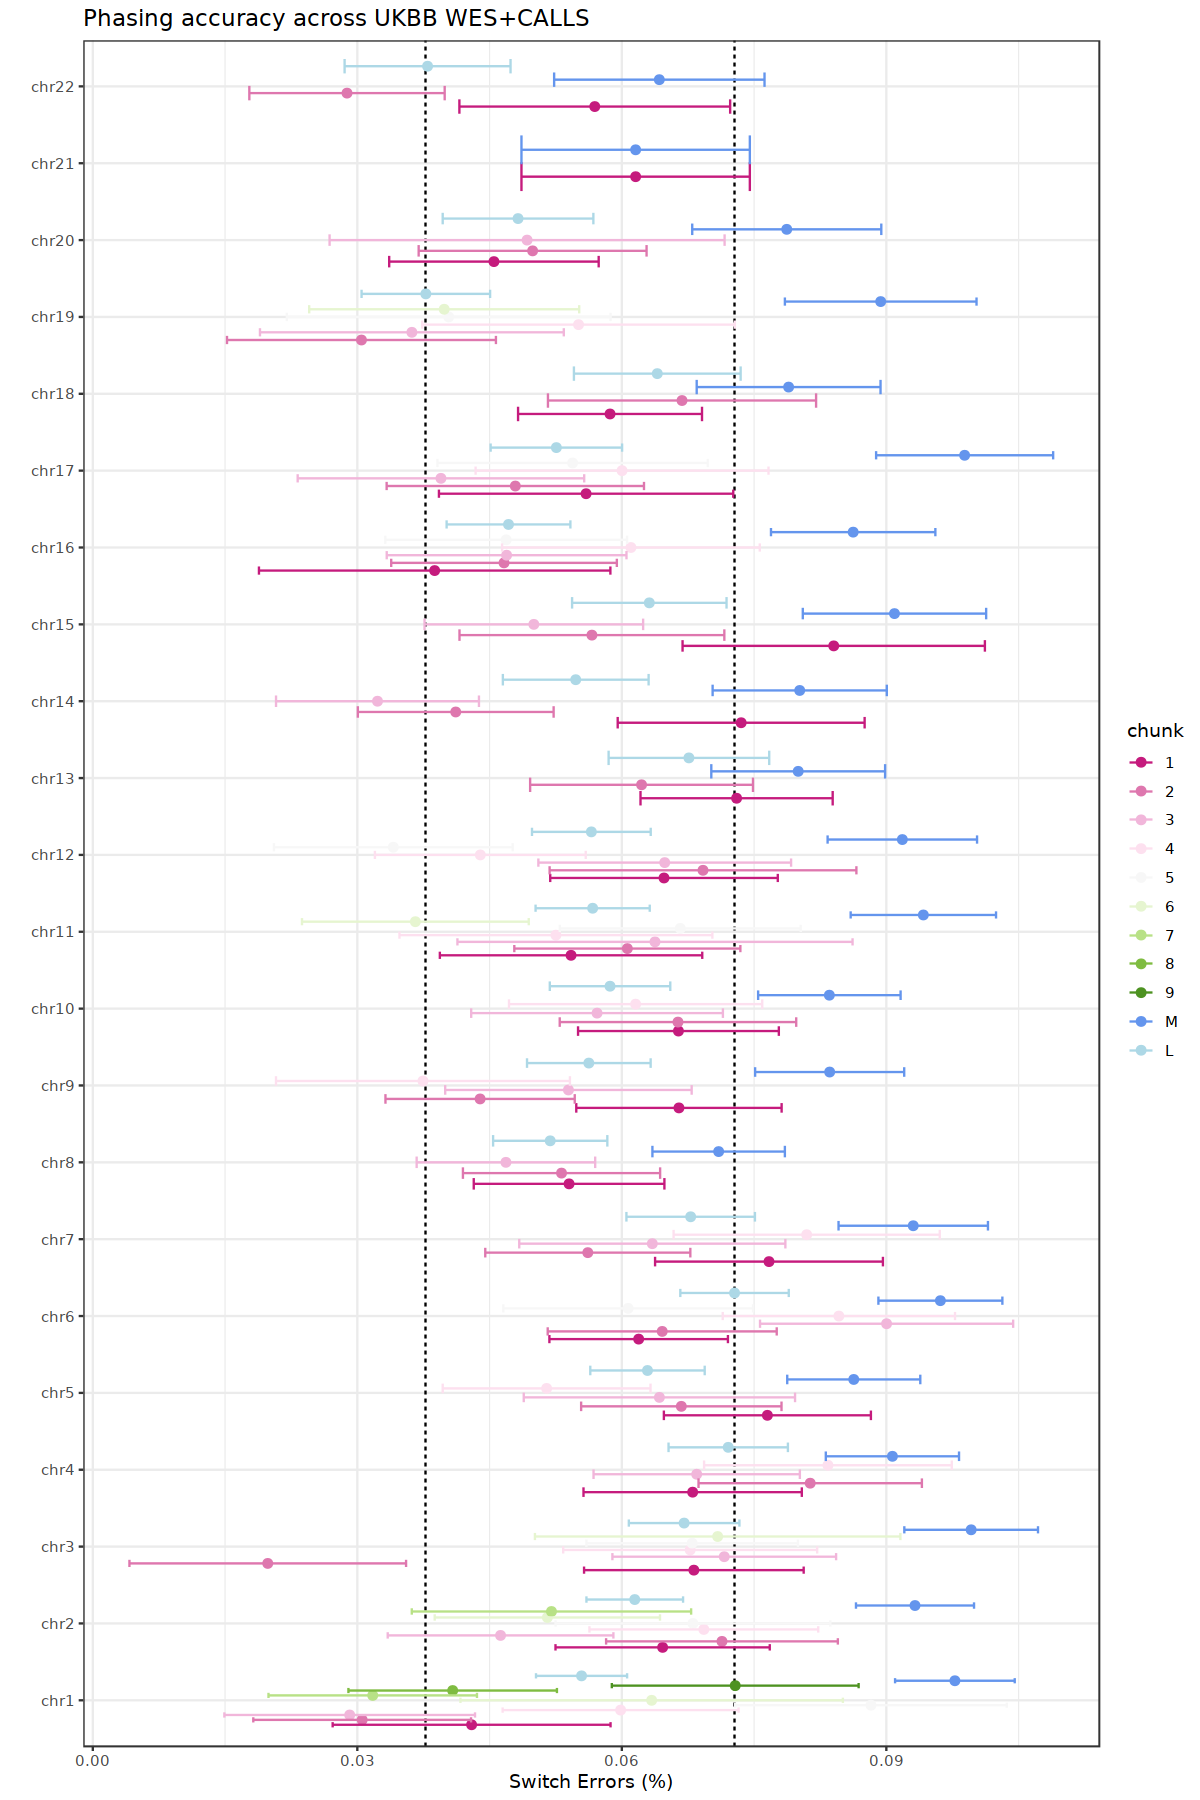

In [9]:
options(repr.plot.width=10, repr.plot.height=15)
plt

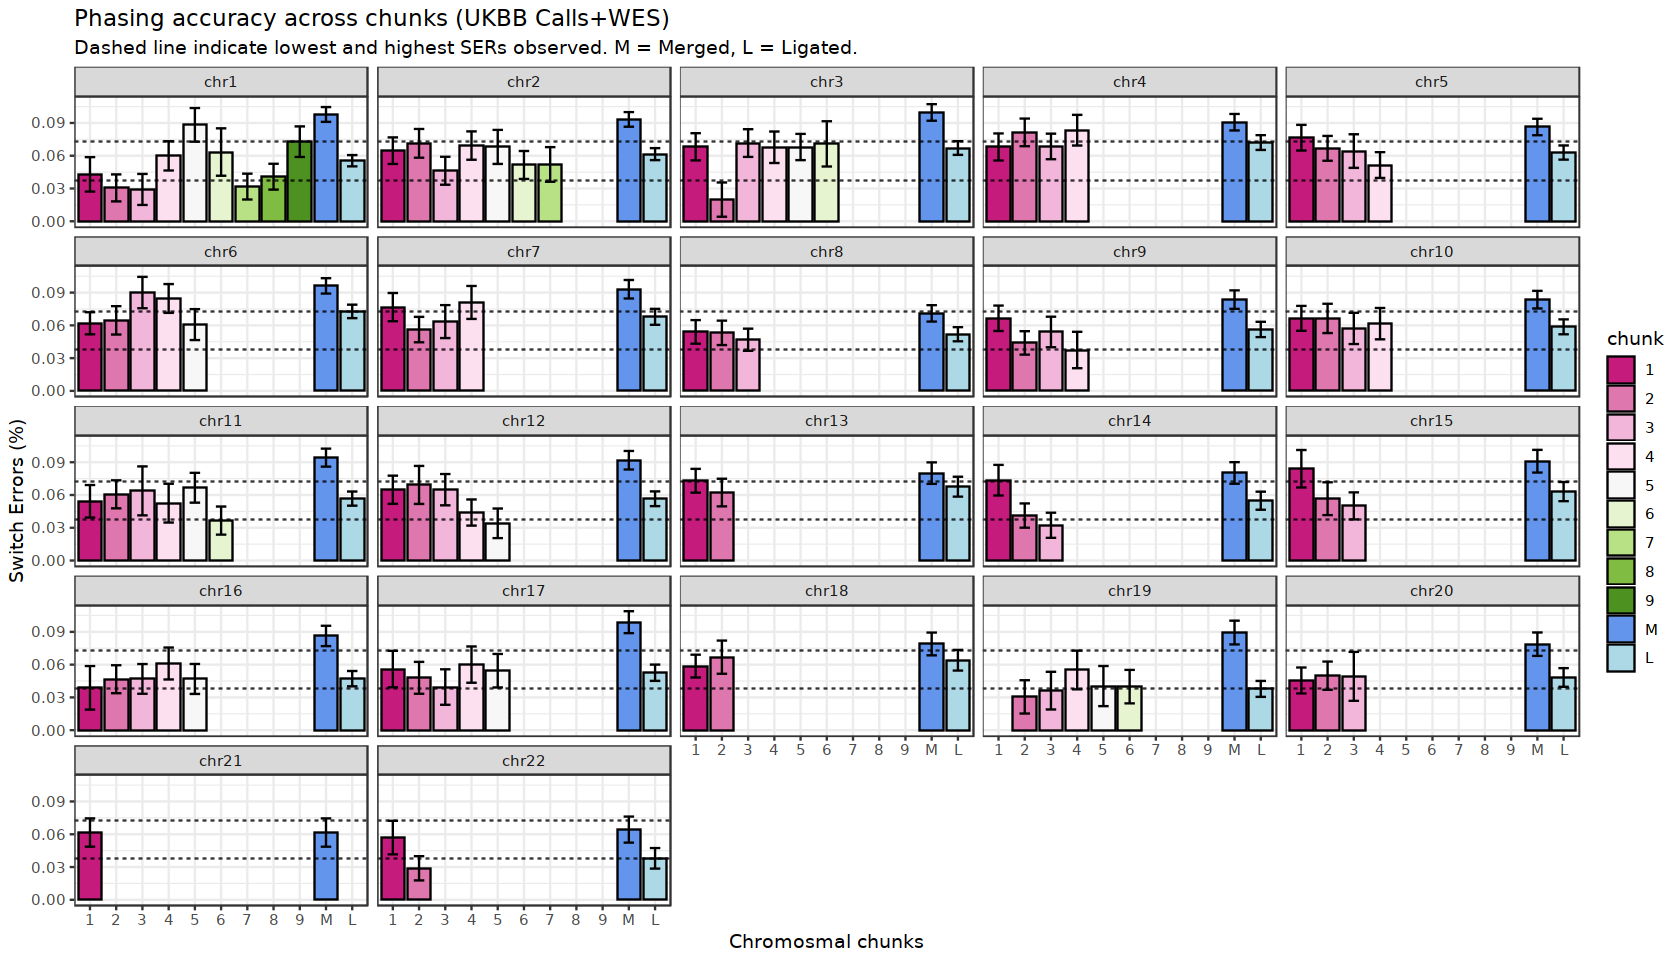

In [11]:
options(repr.plot.width=14, repr.plot.height=8)
pd <- position_dodge2(width = 0.6, preserve = "single")
ggplot(combined,
           aes(
               y=100*ci_ser_est,
               ymax = 100*(ci_ser_est + ci_ser_error),
               ymin = 100*(ci_ser_est - ci_ser_error),
               x = chunk,
               fill = chunk
           )) +
        fillScale +
        geom_bar(stat='identity', color = 'black') +
        geom_hline(yintercept=best_lig$ci_ser_est*100, linetype = 'dashed', col = 'black', alpha = 0.8) +
        geom_hline(yintercept=worst_lig$ci_ser_est*100, linetype = 'dashed', col = 'black', alpha = 0.8) +
        geom_errorbar(stat='identity', position = pd, width = 0.4) +
        ggtitle('Phasing accuracy across chunks (UKBB Calls+WES)',
                'Dashed line indicate lowest and highest SERs observed. M = Merged, L = Ligated.') +
        labs(color = "Phasing chunk(s)") +
        ylab('Switch Errors (%)') + xlab('Chromosmal chunks') +
        theme_bw() +
        facet_wrap(~chr)


In [22]:
chunk_dir <- "data/phased/wes_union_calls/chunks/final/ukb_eur_wes_union_calls_200k_chr10-16xshort.qe"
chunks <- read_chunks_from_dir(chunk_dir)

In [23]:
ligated_dir <- list.files("data/phased/wes_union_calls/ligated/new", full.names = TRUE, pattern = '[0-9]+.txt')
ligated <- read_chunks_combined(ligated_dir[1])
ligated$chunk <- "ligated"
ligated_dir

[1] "data/phased/wes_union_calls/ligated/new/ukb_eur_wes_union_calls_200k_chr10.txt"
[2] "data/phased/wes_union_calls/ligated/new/ukb_eur_wes_union_calls_200k_chr13.txt"
[3] "data/phased/wes_union_calls/ligated/new/ukb_eur_wes_union_calls_200k_chr14.txt"
[4] "data/phased/wes_union_calls/ligated/new/ukb_eur_wes_union_calls_200k_chr18.txt"
[5] "data/phased/wes_union_calls/ligated/new/ukb_eur_wes_union_calls_200k_chr20.txt"
[6] "data/phased/wes_union_calls/ligated/new/ukb_eur_wes_union_calls_200k_chr22.txt"
[7] "data/phased/wes_union_calls/ligated/new/ukb_eur_wes_union_calls_200k_chr4.txt" 
[8] "data/phased/wes_union_calls/ligated/new/ukb_eur_wes_union_calls_200k_chr8.txt"

In [24]:
merged_dir <- list.files(args$in_dir_merge, full.names = TRUE, pattern = '[0-9]+.txt')
merged <- read_chunks_combined(merged_dir[2])
merged$chunk <- "merged"
merged_dir

[1] "data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_chr1.txt" 
 [2] "data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_chr10.txt"
 [3] "data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_chr11.txt"
 [4] "data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_chr12.txt"
 [5] "data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_chr13.txt"
 [6] "data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_chr14.txt"
 [7] "data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_chr15.txt"
 [8] "data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_chr16.txt"
 [9] "data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_chr17.txt"
[10] "data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_chr18.txt"
[11] "data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_chr19.txt"
[12] "data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_chr2.txt" 
[13] "data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_chr20.txt"
[14] "data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_chr21.txt"
[15] "data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_chr22.txt"
[16] "data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_chr3.txt" 
[17] "data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_chr4.txt" 
[18] "data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_chr5.txt" 
[19] "data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_chr6.txt" 
[20] "data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_chr7.txt" 
[21] "data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_chr8.txt" 
[22] "data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_chr9.txt"

In [25]:
mrg <- rbind(chunks, ligated, merged)
max_chunks <- suppressWarnings(max(na.omit(as.numeric(as.character(mrg$chunk)))))
mrg$chunk <- factor(mrg$chunk, levels = as.character(c(1:max_chunks, "merged","ligated")))

In [26]:
mrg <- mrg[sample(1:nrow(mrg),size =  10000),]
#mrg <- mrg[mrg$POS > 2.7e+7 & mrg$POS < 2.8e+7]

In [59]:
trim <- fread('data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr10_trims.txt')
colnames(trim) <- c('dir','prefix','i','mt1_right_flank',  'mt2_left_flank','o','start','end')
trim$midpoint <- trim$mt1_right_flank-trim$mt2_left_flank

[1] 1017995 1933288 1792080

In [27]:
#overlap <- fread('data/phased/wes_union_calls/merged/ukb_eur_wes_union_calls_200k_1_overlap.txt')
#overlap$V4 <- as.numeric(gsub('(\\[)|(\\])','',overlap$V4))
#overlap$V5 <- as.numeric(gsub('(\\[)|(\\])','',overlap$V5))
#overlap$V6 <- overlap$V5 - overlap$V4

In [28]:
colors <- brewer.pal(max_chunks,"Blues")
colors[max_chunks + 1] <- 'orange'
colors[max_chunks + 2] <- 'darkred'
names(colors) <- levels(mrg$chunk)
scale_color <- scale_colour_manual(name = "chunk",values = colors)

In [43]:
n_errors_merged <- max(mrg[mrg$chunk == 'merged']$cumsum)
n_errors_ligated <- max(mrg[mrg$chunk == 'ligated']$cumsum)

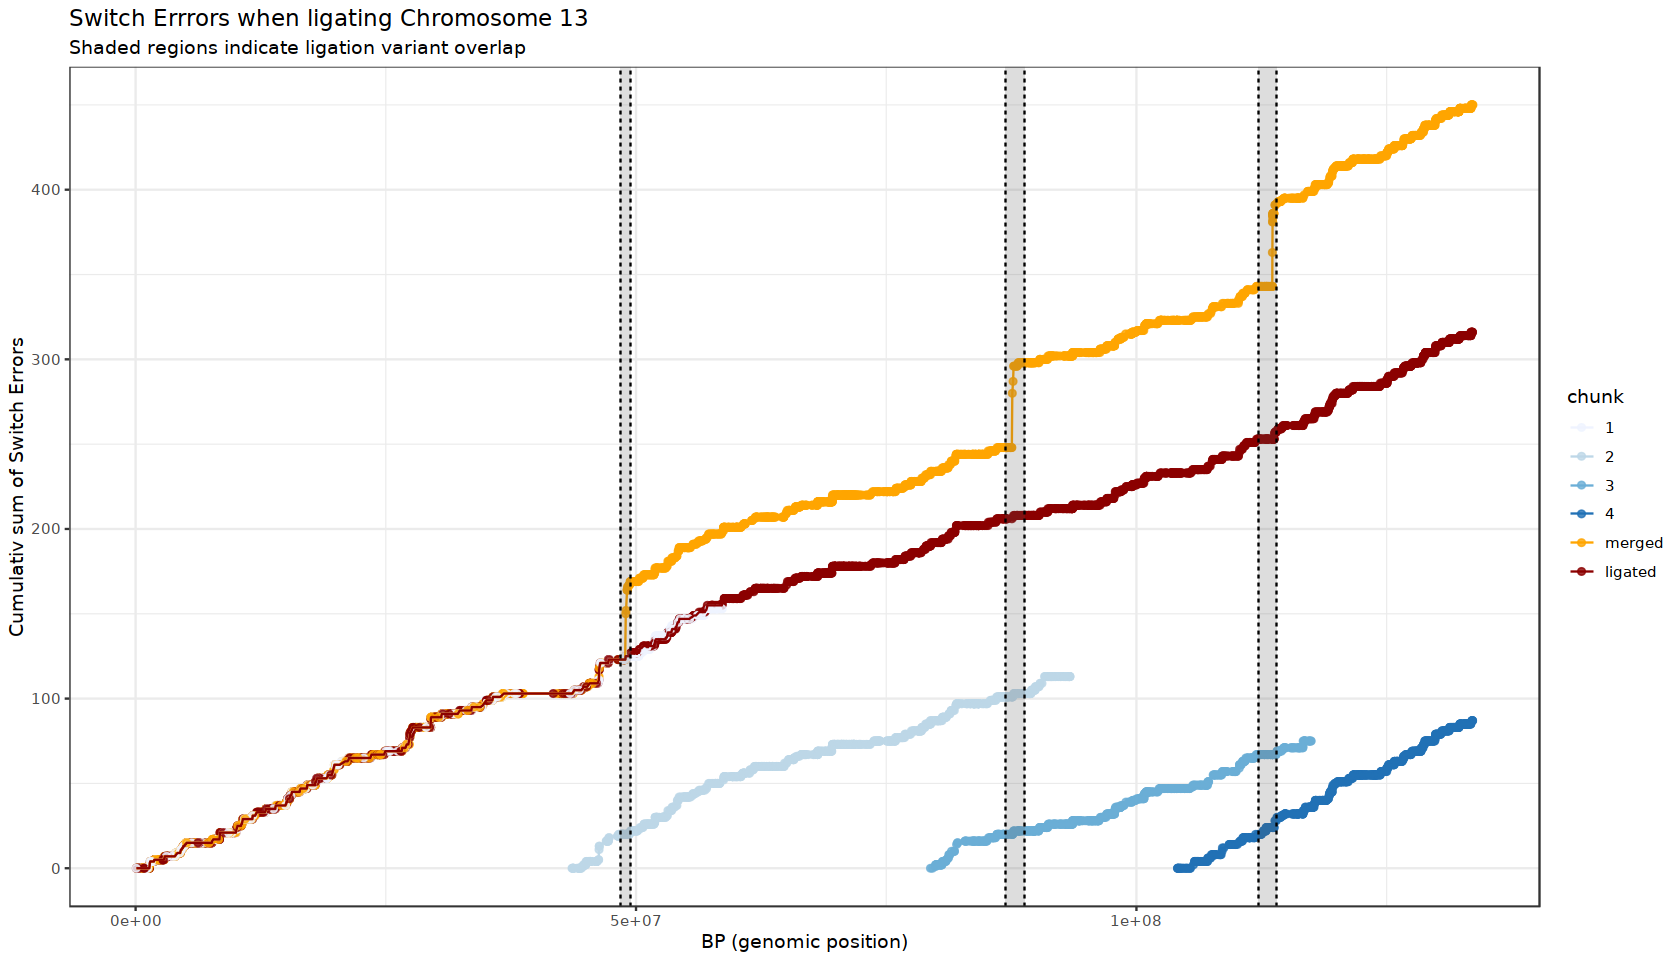

In [57]:
options(repr.plot.width=14, repr.plot.height=8)
ggplot(mrg, aes(x = POS, y = cumsum, group = chunk, color = chunk)) +
    geom_point(alpha = 0.8) +
    geom_line() +
    scale_color +
    annotate("rect", xmin = trim$mt2_left_flank, xmax = trim$mt1_right_flank, 
             ymin = -Inf, ymax = Inf, alpha = .2) +
    geom_vline(xintercept=trim$mt1_right_flank, linetype = 'dashed', color = 'black') +
    geom_vline(xintercept=trim$mt2_left_flank, linetype = 'dashed', color = 'black') +
    xlab("BP (genomic position)") +
    ylab("Cumulativ sum of Switch Errors") +
    theme_bw() +
    ggtitle("Switch Errrors when ligating Chromosome 13",
            "Shaded regions indicate ligation variant overlap")

In [79]:
dm <- data.frame(i = 0:(length(unique(chunks$chunk))) ,slice = c(0, trim$midpoint, max(chunks$POS)))
dm

i,slice
<int>,<dbl>
0,0
1,1017995
2,1933288
3,1792080
4,133625545


In [143]:
new_chunks <- do.call(rbind, lapply(1:nrow(dm), function(i){
    subset <- chunks[chunks$chunk == i]
    #subset <- subset[subset$POS >= dm$slice[i], ]
    subset <- subset[subset$POS < dm$slice[i+2], ]
    print(nrow(subset))
    return(subset)
    #subset < subset[subset$POS < dm$slice[i] & subset$POS < dm$slice[i+1], ]
}))

new_chunks$cumsum <- cumsum(new_chunks$switches)

[1] 10224
[1] 0
[1] 134641
[1] 0
[1] 0


In [138]:
new_mrg <- rbind(new_chunks, ligated, merged)
max_chunks <- suppressWarnings(max(na.omit(as.numeric(as.character(new_mrg$chunk)))))
new_mrg$chunk <- factor(new_mrg$chunk, levels = as.character(c(1:max_chunks, "merged","ligated")))

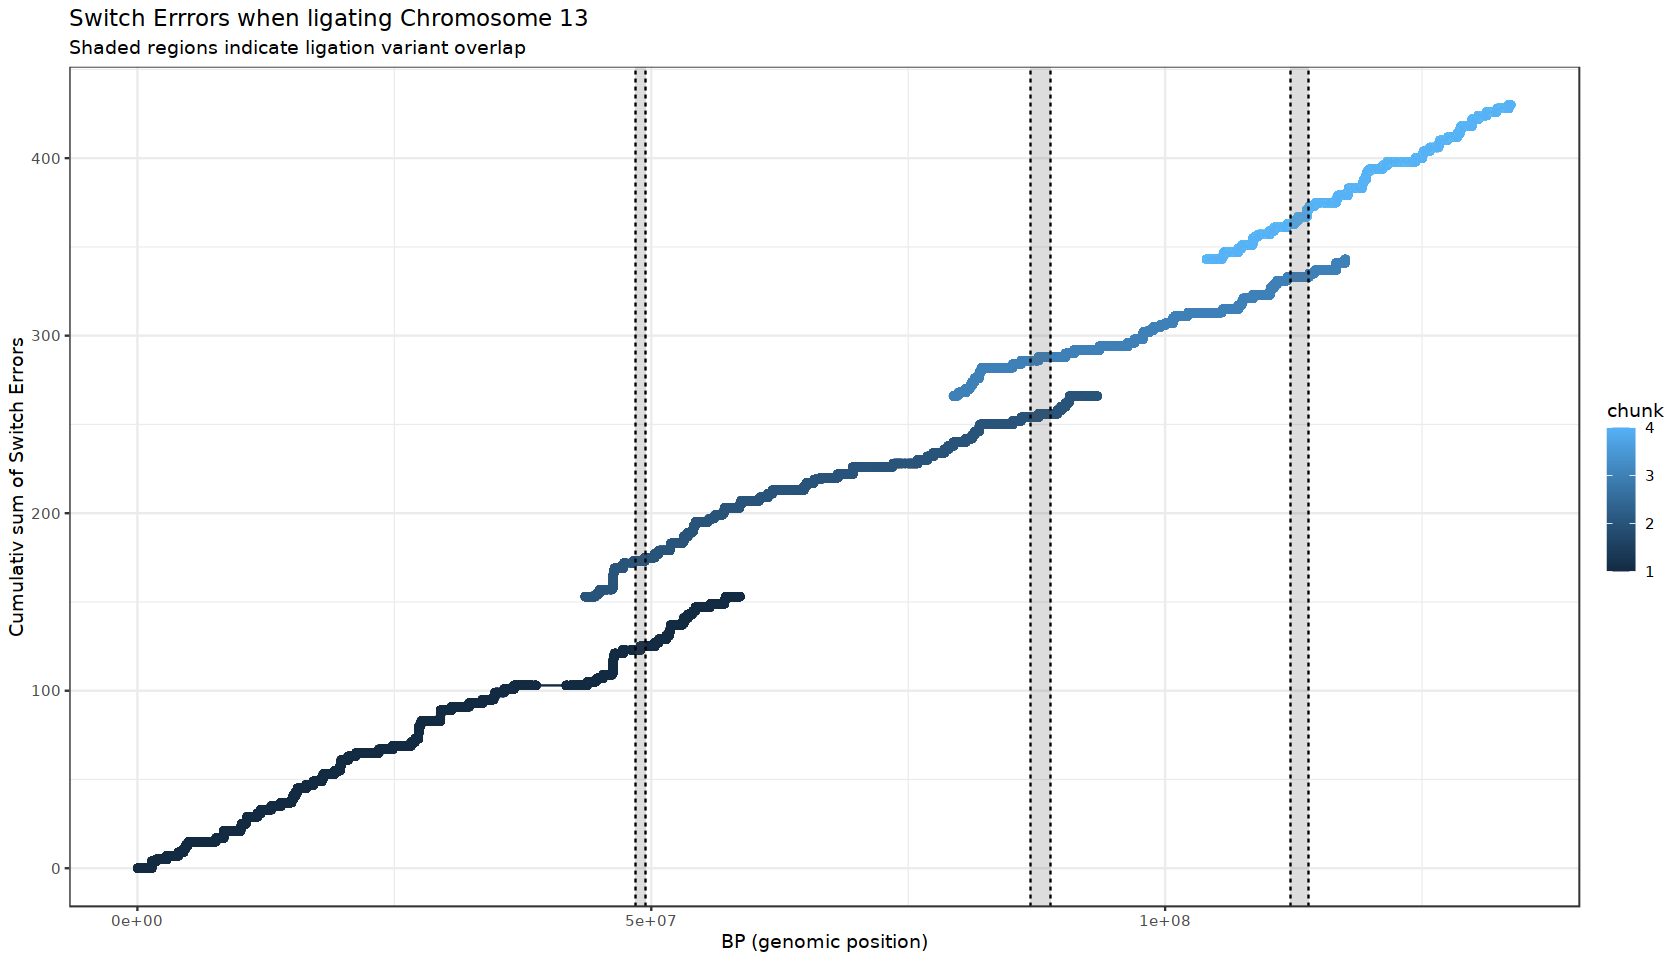

In [139]:
options(repr.plot.width=14, repr.plot.height=8)
ggplot(new_chunks, aes(x = POS, y = cumsum, group = chunk, color = chunk)) +
    geom_point(alpha = 0.8) +
    geom_line() +
    #scale_color +
    annotate("rect", xmin = trim$mt2_left_flank, xmax = trim$mt1_right_flank, 
             ymin = -Inf, ymax = Inf, alpha = .2) +
    geom_vline(xintercept=trim$mt1_right_flank, linetype = 'dashed', color = 'black') +
    geom_vline(xintercept=trim$mt2_left_flank, linetype = 'dashed', color = 'black') +
    xlab("BP (genomic position)") +
    ylab("Cumulativ sum of Switch Errors") +
    theme_bw() +
    ggtitle("Switch Errrors when ligating Chromosome 13",
            "Shaded regions indicate ligation variant overlap")

In [140]:
genes <- fread('/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/protein_coding_genes.tsv')
genes <- genes[genes$chromosome_name == 1,]

do.call(rbind, lapply(overlap$V4, function(bp){
    gdf <- genes[genes$start_position < bp & bp < genes$end_position,]
    gdf$merge_slice_bp <- bp
    gdf$gene_len <- gdf$end_position - gdf$start_position
    return(gdf)
}))

ERROR: Error in lapply(overlap$V4, function(bp) {: object 'overlap' not found


In [18]:
genes <- fread('/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/protein_coding_genes.tsv')

In [19]:
genes$len <- genes$end_position - genes$start_position

In [20]:
quantile(genes$len, probs = 0.8)

80% 
82479.2